In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("GROQ_API_KEY") is None:
    raise ValueError("GROQ_API_KEY is not set")
else:
    print("GROQ_API_KEY is set")

GROQ_API_KEY is set


In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7fe7cacb4ec0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7fe7cacb5be0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

## **Schema**

In [3]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    topic: str
    insta:str
    linkedin:str
    twitter:str


## Now, we will create three nodes for each of the social media platform.

In [4]:
def create_insta_post(state:graph_schema)->graph_schema:

    topic = state["topic"]

    post = llm.invoke(f"Create a post for instagram about {topic}. Keep the tone very funny, casual and engaging under 100 words.")

    state["insta"] = post

    return {"insta":post}

def create_linkedin_post(state:graph_schema)->graph_schema:

    topic = state["topic"]

    post = llm.invoke(f"Create a post for linkedin about {topic}. Keep the tone very professional, formal and engaging under 100 words.")
    
    state["linkedin"] = post

    return {"linkedin":post}

def create_twitter_post(state:graph_schema)->graph_schema:

    topic = state["topic"]

    post = llm.invoke(f"Create a post for twitter about {topic}. Keep the tone very casual, harsh and engaging and under 100 words.")

    state["twitter"] = post

    return {"twitter":post}

## Now, we will create a graph for the parallel execution of the nodes.



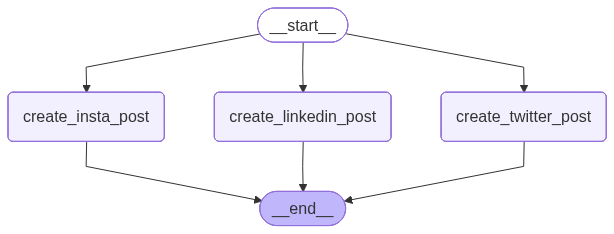

In [6]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_insta_post", create_insta_post)
graph.add_node("create_linkedin_post", create_linkedin_post)
graph.add_node("create_twitter_post", create_twitter_post)

graph.add_edge(START, "create_insta_post")
graph.add_edge(START, "create_linkedin_post")
graph.add_edge(START, "create_twitter_post")

graph.add_edge("create_insta_post", END)
graph.add_edge("create_linkedin_post", END)
graph.add_edge("create_twitter_post", END)

parallel_graph = graph.compile()

from IPython.display import Image, display

Image(parallel_graph.get_graph().draw_mermaid_png())

In [7]:
parallel_graph.invoke({"topic":"Geopolitical tensions"})

{'topic': 'Geopolitical tensions',
 'insta': AIMessage(content='"World leaders, can we just get along? It\'s like, let\'s all just agree to disagree and grab a beer. Geopolitical tensions are so last season. Can we just have a global group hug and move on? #Geopolitics #WorldPeace #BeerForPeace"', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 60, 'total_tokens': 120, 'completion_time': 0.278218932, 'completion_tokens_details': None, 'prompt_time': 0.023229943, 'prompt_tokens_details': None, 'queue_time': 0.075020816, 'total_time': 0.301448875}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1f7d-0c08-7261-8903-9be5aebcbaab-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 60, 'output_tokens': 60, 'total_tokens': 120}),
 'linkedin': AIMessage(content='"As global lea